# LSTM - Dataset (sexism-socialmedia-balanced)

In [1]:
!pip install -q tensorflow scikit-learn matplotlib seaborn wordcloud

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import pickle
import os

os.makedirs('/content/models/lstm_dsmb', exist_ok=True)

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
df = pd.read_csv('/content/sexism-socialmedia-balanced.csv')
df['text'] = df['text'].str.lower()

print('Shape:', df.shape)
print('Label distribution:')
print(df['label'].value_counts())

Shape: (20108, 2)
Label distribution:
label
1    10059
0    10049
Name: count, dtype: int64


In [4]:
X = df['text'].astype(str)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vocab_size = 10000
embedding_dim = 100
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

with open('/content/models/lstm_dsmb/tokenizer.pickle', 'wb') as f:
    pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=max_length, padding='post', truncating='post')

In [5]:
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
    Dropout(0.5),
    Bidirectional(LSTM(32, kernel_regularizer=l2(0.001))),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5, verbose=1)

history = model.fit(
    X_train_pad, y_train,
    epochs=6,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

model.save('/content/models/lstm_dsmb/sexism_model.h5')

Epoch 1/6
252/252 ━━━━━━━━━━━━━━━━━━━━ 117s 383ms/step - accuracy: 0.5237 - loss: 1.1569 - val_accuracy: 0.5012 - val_loss: 1.0498 - learning_rate: 1.0000e-04
Epoch 2/6
252/252 ━━━━━━━━━━━━━━━━━━━━ 94s 374ms/step - accuracy: 0.6159 - loss: 0.9551 - val_accuracy: 0.7417 - val_loss: 0.7778 - learning_rate: 1.0000e-04
Epoch 3/6
252/252 ━━━━━━━━━━━━━━━━━━━━ 94s 371ms/step - accuracy: 0.7747 - loss: 0.6849 - val_accuracy: 0.7887 - val_loss: 0.6256 - learning_rate: 1.0000e-04
Epoch 4/6
252/252 ━━━━━━━━━━━━━━━━━━━━ 142s 373ms/step - accuracy: 0.8326 - loss: 0.5463 - val_accuracy: 0.8016 - val_loss: 0.5630 - learning_rate: 1.0000e-04
Epoch 5/6
252/252 ━━━━━━━━━━━━━━━━━━━━ 146s 391ms/step - accuracy: 0.8609 - loss: 0.4582 - val_accuracy: 0.8081 - val_loss: 0.5311 - learning_rate: 1.0000e-04
Epoch 6/6
252/252 ━━━━━━━━━━━━━━━━━━━━ 142s 393ms/step - accuracy: 0.8821 - loss: 0.4006 - val_accuracy: 0.8158 - val_loss: 0.5230 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best

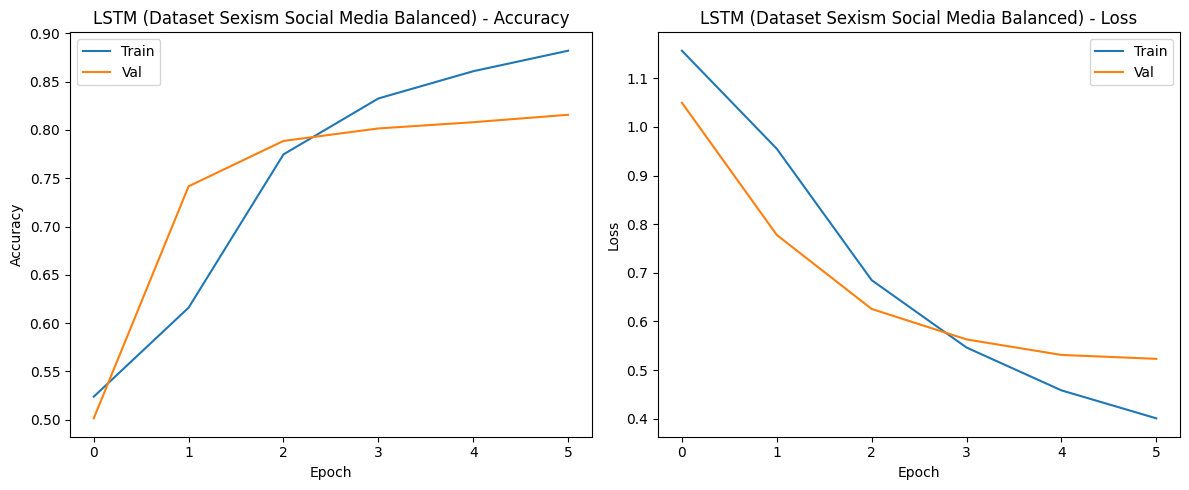

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('LSTM (Dataset Sexism Social Media Balanced) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('LSTM (Dataset Sexism Social Media Balanced) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('/content/models/lstm_dsmb/training_history.png', dpi=150)
plt.show()

126/126 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step


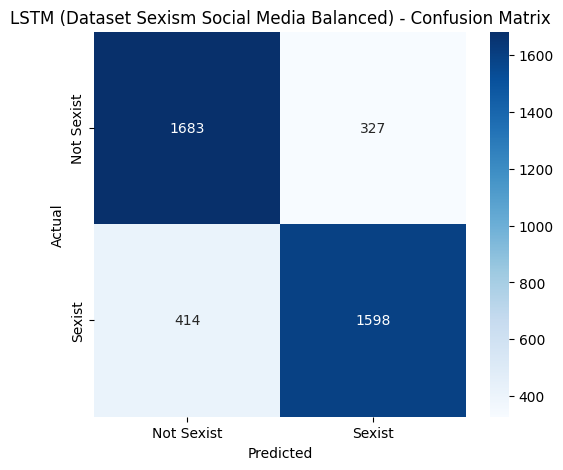

              precision    recall  f1-score   support

  Not Sexist       0.80      0.84      0.82      2010
      Sexist       0.83      0.79      0.81      2012

    accuracy                           0.82      4022
   macro avg       0.82      0.82      0.82      4022
weighted avg       0.82      0.82      0.82      4022



In [8]:
y_pred = (model.predict(X_test_pad) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Sexist', 'Sexist'], yticklabels=['Not Sexist', 'Sexist'])
plt.title('LSTM (Dataset Sexism Social Media Balanced) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/models/lstm_dsmb/confusion_matrix.png', dpi=150)
plt.show()

report = classification_report(y_test, y_pred, target_names=['Not Sexist', 'Sexist'])
print(report)

with open('/content/models/lstm_dsmb/metrics.txt', 'w') as f:
    f.write(report)
    f.write('\nConfusion Matrix:\n')
    f.write(str(cm))

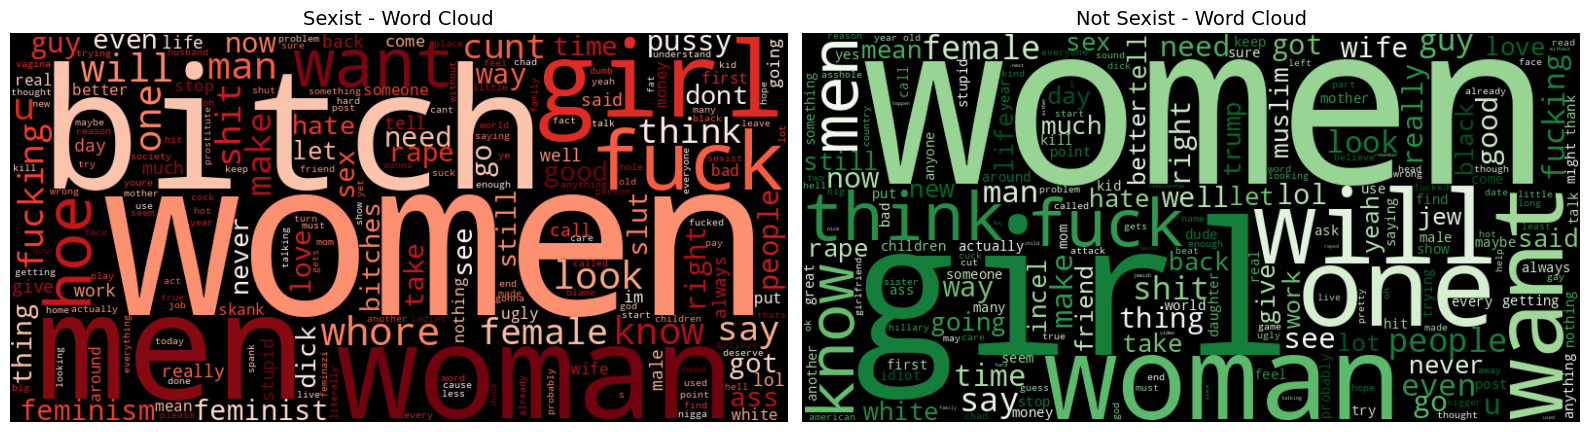

In [9]:
sexist_text = ' '.join(df[df['label'] == 1]['text'].dropna().astype(str).tolist())
clean_text = ' '.join(df[df['label'] == 0]['text'].dropna().astype(str).tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
wc_s = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(sexist_text)
wc_c = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(clean_text)

axes[0].imshow(wc_s, interpolation='bilinear')
axes[0].set_title('Sexist - Word Cloud', fontsize=14)
axes[0].axis('off')

axes[1].imshow(wc_c, interpolation='bilinear')
axes[1].set_title('Not Sexist - Word Cloud', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('/content/models/lstm_dsmb/wordclouds.png', dpi=150)
plt.show()

In [10]:
import shutil
shutil.make_archive('/content/lstm_dsmb_results', 'zip', '/content/models/lstm_dsmb')

'/content/lstm_dsmb_results.zip'